In [ ]:
import os
import re
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from nilearn.image import load_img, math_img, concat_imgs
from nilearn.glm.first_level import FirstLevelModel
from nilearn.maskers import NiftiMasker

from sklearn.svm import LinearSVC
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")


In [ ]:
def central_split_index(labels):
    labels = np.asarray(labels)
    transitions = np.where(labels[:-1] != labels[1:])[0] + 1
    if len(transitions) == 0:
        raise ValueError("No label transitions found.")
    center = len(labels) / 2
    return transitions[np.argmin(np.abs(transitions - center))]

subjects = [f"sub_{i:02d}" for i in range(2, 23)]
subject_data = {}  # store betas, labels, groups per subject
for subj in subjects:

    print(f"Precomputing betas for {subj}")
    sub = subj
    t_r = 1.23

    bold1 = f".../{sub}/func/r{sub}_run1.nii"
    bold2 = f"/.../{sub}/func/r{sub}_run2.nii"

    ev1 = f".../text_files/{sub}/run_1/motivation_1.txt"
    ev2 = f".../text_files/{sub}/run_2/motivation_2.txt"

    seed_mask1_path = f".../masks/vmpfc/individual_masks/{sub}_run1.nii.gz"
    seed_mask2_path = f".../masks/vmpfc/individual_masks/{sub}_run2.nii.gz"

    # --- Events ---
    def read_events(p):
        return pd.read_csv(p, sep=r"\s+", header=None,
                           names=["onset", "duration", "value"])

    ev_df1 = read_events(ev1)
    ev_df2 = read_events(ev2)

    def prep_events(ev_df, run):
        df = ev_df.copy().reset_index(drop=True)
        df["orig_label"] = df["value"].astype(int).replace(-1, 0)
        df["trial_type"] = [f"trial_run{run}_{i}" for i in range(len(df))]
        return df

    events_run1 = prep_events(ev_df1, 1)
    events_run2 = prep_events(ev_df2, 2)

    labels1 = events_run1["orig_label"].values
    labels2 = events_run2["orig_label"].values

    # Fixed CV split points
    split1 = central_split_index(labels1)
    split2 = central_split_index(labels2)

    groups = np.concatenate([
        ["run1_first"] * split1 + ["run1_second"] * (len(labels1) - split1),
        ["run2_first"] * split2 + ["run2_second"] * (len(labels2) - split2)
    ])

    # --- Mask ---
    sm1 = load_img(seed_mask1_path)
    sm2 = load_img(seed_mask2_path)
    combined_mask = math_img("img1 + img2 > 0",
                             img1=math_img("img > 0.001", img=sm1),
                             img2=math_img("img > 0.001", img=sm2))

    # --- GLM ---
    flm = FirstLevelModel(
        t_r=t_r,
        hrf_model="spm",
        drift_model="cosine",
        high_pass=0.01,
        smoothing_fwhm=6,
        n_jobs=1
    )

    def get_betas(bold, events, run):
        fm = flm.fit(bold, events)
        design = fm.design_matrices_[0]
        cols = sorted(
            [c for c in design.columns if c.startswith(f"trial_run{run}_")],
            key=lambda x: int(x.split("_")[-1])
        )
        betas = [fm.compute_contrast(c, output_type="effect_size") for c in cols]
        return betas

    betas = get_betas(bold1, events_run1, 1) + \
            get_betas(bold2, events_run2, 2)

    y = np.concatenate([labels1, labels2])

    masker = NiftiMasker(mask_img=combined_mask, standardize=False)
    masker.fit()

    # Extract voxel values for each trial
    X = masker.transform(betas) 

    # Collapse to single value per trial (mean across voxels)
    mPFC_betas = X.mean(axis=1)

    subject_data[subj] = {
        "betas": betas,
        "mPFC_betas": mPFC_betas, 
        "labels": y,
        "groups": groups,
        "mask": combined_mask
    }


In [ ]:
rows = []

for subj, d in subject_data.items():
    n = len(d["mPFC_betas"])
    for i in range(n):
        rows.append({
            "subject": subj,
            "trial": i,
            "mPFC_beta": d["mPFC_betas"][i],
            "choice": d["labels"][i]  # adjust if needed
        })

df = pd.DataFrame(rows)

df.to_csv("trialwise_vmpfc.csv", index=False)

In [ ]:
# build cv accuracy array
accuracy = []

for subj, d in subject_data.items():
    y = d["labels"].copy()

    pipe = Pipeline([
        ("masker", NiftiMasker(
            mask_img=combined_mask,
            standardize=True
        )),
        ("clf", LinearSVC(
            C=1.0,
            max_iter=10000,
            dual=False
        ))
    ])

    pipe.set_params(masker__mask_img=d["mask"])
    cv = GroupKFold(n_splits=4)

    scores = cross_val_score(
        pipe,
        d["betas"],
        y,
        cv=cv,
        groups=d["groups"],
        scoring="accuracy"
    )

    accuracy.append(scores.mean())

# get mean accuracy for test stat
test = np.mean(accuracy)

In [ ]:
# now lets get a null distribution by doing a circular shuffle/rotation within runs for each participant
# recalculate accuracy 

n_perms = 500
null_dist_new = []

rng = np.random.default_rng(123)

for p in range(n_perms):
    perm_acc = []

    for subj, d in subject_data.items():
        y = d["labels"].copy()

        # circular shift WITHIN RUNS
        n1 = np.sum(d["groups"] == "run1_first") + np.sum(d["groups"] == "run1_second")
        shift1 = rng.integers(1, n1)
        shift2 = rng.integers(1, len(y) - n1)

        y[:n1] = np.roll(y[:n1], shift1)
        y[n1:] = np.roll(y[n1:], shift2)

        pipe = Pipeline([
            ("masker", NiftiMasker(
                mask_img=combined_mask,
                standardize=True
            )),
            ("clf", LinearSVC(
                C=1.0,
                max_iter=10000,
                dual=False
            ))
        ])

        pipe.set_params(masker__mask_img=d["mask"])
        cv = GroupKFold(n_splits=4)

        scores = cross_val_score(
            pipe,
            d["betas"],
            y,
            cv=cv,
            groups=d["groups"],
            scoring="accuracy"
        )

        perm_acc.append(scores.mean())

    null_dist_new.append(np.mean(perm_acc))

null_dist = np.array(null_dist_new)
# null_dist = pd.read_csv('null_dist_500.csv')

In [ ]:
null_dist = np.array(null_dist)
p = np.mean(null_dist > test)
print(p)

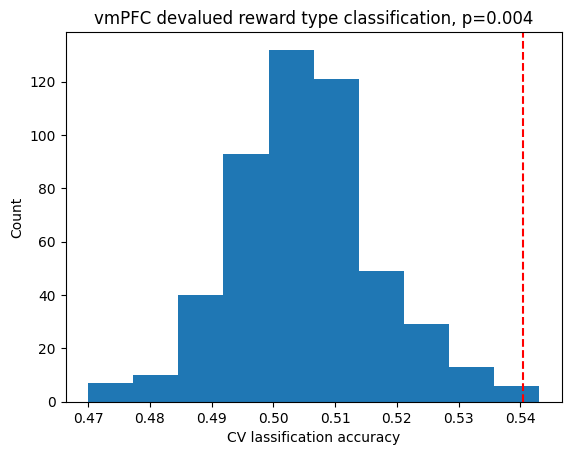

In [16]:
plt.hist(null_dist)
plt.axvline(test,c='red',linestyle='--')
plt.xlabel('CV lassification accuracy')
plt.ylabel('Count')
plt.title('vmPFC devalued reward type classification, p=0.004')
plt.savefig('vmPFC_classification.svg')